In [2]:
import pandas as pd

df = pd.read_csv("students.csv")

print(df.shape)
print(df.head())

(15, 9)
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [4]:
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)


Shape of dataset: (15, 9)

Data types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [5]:
print("\nSummary statistics:\n", df.describe())


Summary statistics:
             math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%              

In [6]:
print("\nPass/Fail count:\n", df['passed'].value_counts())



Pass/Fail count:
 passed
1    9
0    6
Name: count, dtype: int64


In [7]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("\nAverage scores of PASS students:\n", pass_avg)
print("\nAverage scores of FAIL students:\n", fail_avg)


Average scores of PASS students:
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average scores of FAIL students:
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [8]:
# calculating average score for each student
df['avg_score'] = df[subject_cols].mean(axis=1)

# find max
top_student = df.loc[df['avg_score'].idxmax()]

print("\nTop student based on average:\n")
print(top_student['name'], "with average =", top_student['avg_score'])


Top student based on average:

Diana with average = 94.0


In [10]:
import matplotlib.pyplot as plt
df['avg_score'] = df[subject_cols].mean(axis=1)

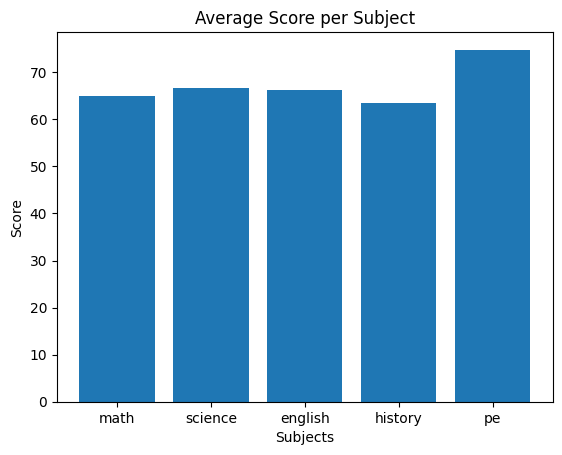

In [11]:
avg_scores = df[subject_cols].mean()

plt.bar(subject_cols, avg_scores)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Score")
plt.savefig("plot1_bar.png")
plt.show()

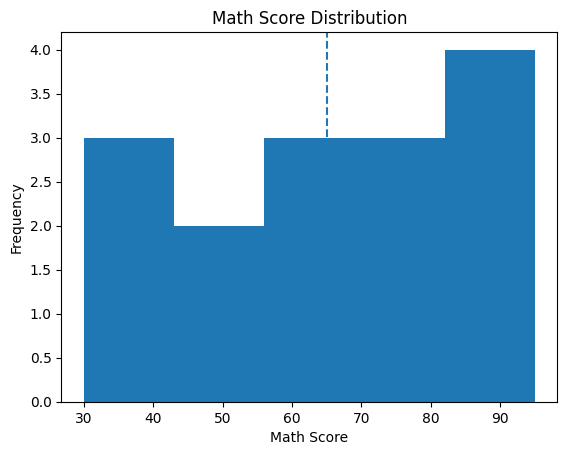

In [12]:
plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed')

plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.savefig("plot2_hist.png")
plt.show()

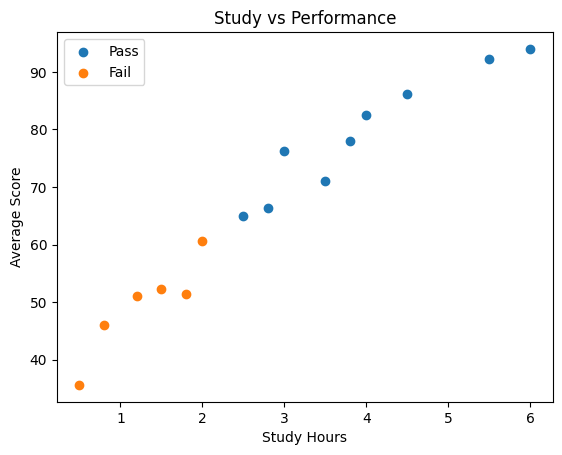

In [13]:
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.title("Study vs Performance")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_716/1692124440.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])


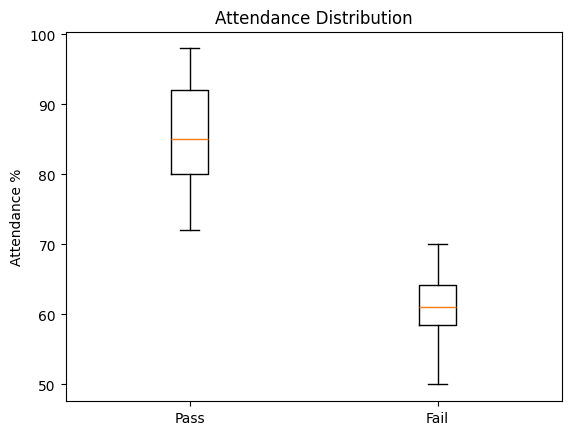

In [14]:
pass_att = pass_df['attendance_pct']
fail_att = fail_df['attendance_pct']

plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

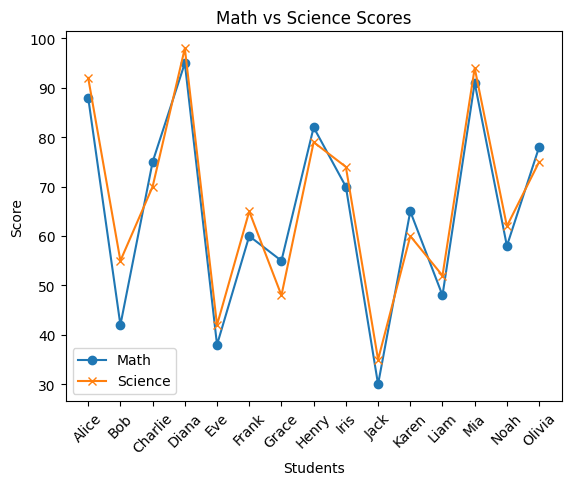

In [15]:
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)

plt.title("Math vs Science Scores")
plt.xlabel("Students")
plt.ylabel("Score")
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

In [16]:
import seaborn as sns

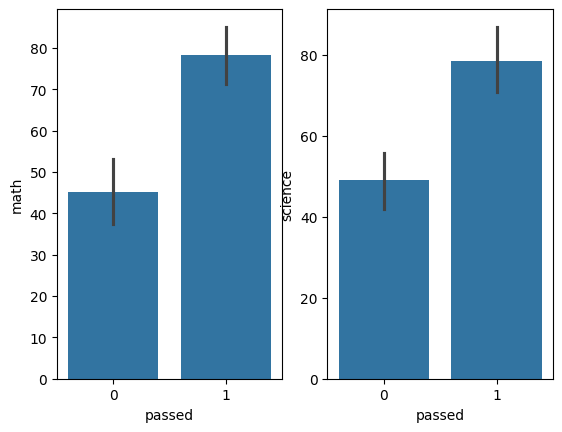

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2)

sns.barplot(data=df, x='passed', y='math', ax=ax1)
sns.barplot(data=df, x='passed', y='science', ax=ax2)

plt.savefig("plot6_seaborn_bar.png")
plt.show()

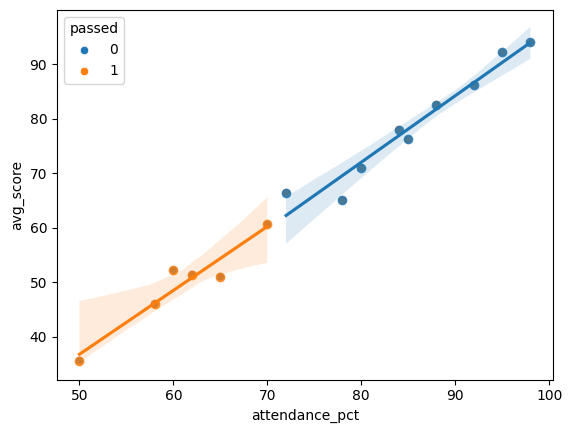

In [19]:
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score')

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Seaborn is easier for statistical plots and requires less code.
# Matplotlib gives more control but requires more manual work.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [21]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Training accuracy:", model.score(X_train_scaled, y_train))

Training accuracy: 1.0


In [23]:
y_pred = model.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 1.0


In [24]:
for i in range(len(X_test)):
    name = df.loc[X_test.index[i], 'name']
    actual = y_test.iloc[i]
    pred = y_pred[i]

    result = "✅" if actual == pred else "❌"
    print(name, actual, pred, result)

Jack 0 0 ✅
Liam 0 0 ✅
Alice 1 1 ✅


In [25]:
coeff = model.coef_[0]
features = X.columns

importance = sorted(zip(features, coeff), key=lambda x: abs(x[1]), reverse=True)

print(importance)

[('english', np.float64(0.8125127982724648)), ('attendance_pct', np.float64(0.521876340433209)), ('study_hours_per_day', np.float64(0.4844326627100155)), ('pe', np.float64(0.47497406284967797)), ('math', np.float64(0.43794393086873595)), ('science', np.float64(0.3230097624690249)), ('history', np.float64(0.26292892629062437))]


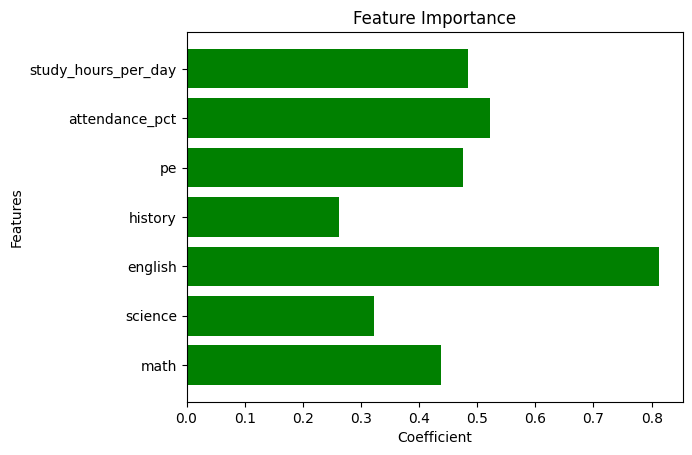

In [26]:
colors = ['green' if c > 0 else 'red' for c in coeff]

plt.barh(features, coeff, color=colors)
plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Features")

plt.show()

In [27]:
new_student = [[75,70,68,65,80,82,3.2]]

scaled = scaler.transform(new_student)

pred = model.predict(scaled)
prob = model.predict_proba(scaled)

print("Prediction:", "Pass" if pred[0]==1 else "Fail")
print("Probability:", prob)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
